<a href="https://colab.research.google.com/github/wuhao007/haowu999/blob/main/kaggle_haowu999.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!curl -L -o bitcoin-historical-data.zip https://www.kaggle.com/api/v1/datasets/download/mczielinski/bitcoin-historical-data

import zipfile
import pandas as pd

zip_ref = zipfile.ZipFile('bitcoin-historical-data.zip', 'r')
zip_ref.extractall('.')
zip_ref.close()

# Load the desired CSV file from the extracted contents
df = pd.read_csv('btcusd_1-min_data.csv')

# Display the first few rows of the DataFrame to confirm it's loaded correctly
display(df.head())

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  101M  100  101M    0     0  93.1M      0  0:00:01  0:00:01 --:--:--  136M


,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [ ]:
import datetime
import numpy as np
import pandas as pd
import requests
from sklearn.linear_model import LinearRegression
import math

_AHR999_DAYS = 200

# Re-define the Haowu999 class with improved structure and comments
class Haowu999:
    """
    A class to calculate and interpret the AHR999 and Pi indicators for cryptocurrency price data.
    It also provides functionality for calculating the Relative Strength Index (RSI) and performing
    logarithmic regression analysis on historical price data.
    """

    def __init__(self, coin, vs_currency, start_date, data_df):
        """
        Initializes the Haowu999 object.

        Args:
            coin: The cryptocurrency ticker symbol (e.g., 'bitcoin').
            vs_currency: The fiat currency to compare against (e.g., 'usd').
            start_date: The start date for calculations in '%Y-%m-%dT%H:%M:%S' format.
            data_df: DataFrame containing historical price data with 'Timestamp' and 'Close' columns.
        """
        if not isinstance(data_df, pd.DataFrame) or data_df.empty:
            raise ValueError("Input data_df must be a non-empty pandas DataFrame.")
        if 'Timestamp' not in data_df.columns or 'Close' not in data_df.columns:
             raise ValueError("Input data_df must contain 'Timestamp' and 'Close' columns.")

        self.coin = coin
        self.vs_currency = vs_currency
        try:
            self.start_date = self._parse_date(start_date)
        except ValueError:
            raise ValueError("Invalid start_date format. Please use '%Y-%m-%dT%H:%M:%S'.")
        # Process raw data to get 'Date' and 'Close' columns
        self.prices = self._process_data(data_df)
        # Initialize instance variables
        self.dates = None
        self.ydata = None
        self.predicted_ydata = None
        self.w, self.b = self._calculate_regression_params()
        self.ahr999_prices = None


    def _calculate_regression_params(self):
        """
        Calculates the regression line parameters (w and b) for logarithmic price vs. logarithmic time.

        Returns:
            A tuple (w, b) containing the slope and intercept of the regression line.
        """
        prices = self.prices
        if prices.empty:
             raise ValueError("Price data is empty, cannot calculate regression parameters.")

        self.dates = pd.to_datetime(prices['Date'])
        # Calculate the number of days since the start date
        coin_days = (self.dates - self.start_date).dt.days

        # Take the logarithm of the days, ensuring no log of zero
        log_coin_days = np.log10([max(1e-9, d) for d in coin_days])

        # Reshape xdata for the regression model
        xdata = log_coin_days.reshape(-1, 1)
        # Take the logarithm of the closing prices
        prices = self.prices[self.prices['Close'] > 0].copy()
        self.ydata = np.log10(prices['Close'].astype(float)).values


        if len(xdata) < 2 or len(self.ydata) < 2:
             raise ValueError("Not enough data points to perform linear regression.")

        # Perform linear regression
        reg = LinearRegression().fit(xdata, self.ydata)
        w, b = reg.coef_[0], reg.intercept_

        # Predict log prices based on the regression line
        self.predicted_ydata = reg.predict(xdata)

        print(f'Score:\033[31m{reg.score(xdata, self.ydata)}\033[0m')
        print(f'w: {w}, b: {b}')
        return w, b

    def _get_past_ahr999_data(self):
        """
        Retrieves the last _AHR999_DAYS of price data for AHR999 calculation.

        Returns:
            A DataFrame containing the recent price data.

        Raises:
            ValueError: If there are not enough data points.
        """
        if len(self.prices) < _AHR999_DAYS:
             raise ValueError(f"Not enough data points. Need at least {_AHR999_DAYS} but got {len(self.prices)}")

        return self.prices.tail(_AHR999_DAYS).copy()

    def _process_data(self, data_df):
        """
        Processes the raw data DataFrame to ensure correct date format and select relevant columns.

        Args:
            data_df: The raw input DataFrame.

        Returns:
            A DataFrame with 'Date' and 'Close' columns.
        """
        # Convert Timestamp to datetime and format
        data_df['Date'] = pd.to_datetime(data_df['Timestamp'], unit='s')
        # data_df['Date'] = data_df['Date'].dt.strftime('%Y-%m-%dT%H:%M:%S')

        # Resample to daily ('1D') frequency, taking the last Close price of the day
        daily_df = data_df.set_index('Date').resample('1D').last().reset_index()

        # Drop any days that might be NaN due to missing data
        daily_df = daily_df.dropna(subset=['Close'])

        # Format the date back to string if needed for downstream methods
        daily_df['Date'] = daily_df['Date'].dt.strftime('%Y-%m-%dT%H:%M:%S')

        return data_df[['Date', 'Close']]

    def _analyze_ahr999(self, ahr999_value):
        """
        Prints the interpretation of the AHR999 value.

        Args:
            ahr999_value: The calculated AHR999 value.
        """
        if ahr999_value is None or np.isnan(ahr999_value):
            print('\033[31mInterpretation: AHR999 value is not available.\033[0m')
        elif ahr999_value < 0.45:
            print('\033[31mInterpretation: Basically a Fire Sale\033[0m')
        elif ahr999_value < 1.2:
            print('\033[31mInterpretation: Accumulate\033[0m')
        elif ahr999_value < 3 / 0.45:
            print('\033[31mInterpretation: HOLD!\033[0m')
        else:
            print('\033[31mInterpretation: FOMO intensifies\033[0m')

    def get_past_ahr999(self):
        """
        Calculates and prints the past AHR999 indicator values and interpretation.
        """
        try:
            self.ahr999_prices = self._get_past_ahr999_data()
        except ValueError as e:
            print(f"Error getting past AHR999 data: {e}")
            return

        print("--- AHR999 Indicator Analysis ---")
        try:
            latest_price_data = self.ahr999_prices.iloc[-1]
            print(f'Date: {latest_price_data["Date"]}')
            avg_price = self._get_average_price(self.ahr999_prices)
            print(f'200 days average price: {avg_price:.2f} {self.vs_currency}')
            log_price = self._get_log_price(latest_price_data["Date"])
            print(f'Log price: {log_price:.2f} {self.vs_currency}')
            days_since_start = self._get_days_since_start(latest_price_data["Date"])
            print(f'Days: {days_since_start} days')
            print(f'Yesterday price: {latest_price_data["Close"]:.2f} {self.vs_currency}')

            ahr999_value = self._calculate_ahr999()
            ahr999x_value = self._calculate_ahr999x()

            print(f'ahr999: {ahr999_value:.2f}')
            print(f'ahr999x: {ahr999x_value:.2f}')
            self._analyze_ahr999(ahr999_value)
        except Exception as e:
             print(f"Error calculating or printing past AHR999 data: {e}")
        finally:
             print("-" * 30)


    def get_today_ahr999(self, price):
        """
        Calculates and prints today's AHR999 indicator values and interpretation based on a given price.

        Args:
            price: The current price of the cryptocurrency.

        Returns:
            A tuple containing the price thresholds for AHR999 0.45, AHR999 1.2, and AHR999x 0.45.
        """
        if not isinstance(price, (int, float)):
            print("Warning: Current price is not a valid number.")
            price = None # Set price to None to indicate it's not valid

        ahr999_045, ahr999_120, ahr999x_045 = np.nan, np.nan, np.nan

        try:
            ratio = 0.45
            ahr999_045 = self._get_ahr999_threshold(ratio)
            print(f'ahr999={ratio}: {ahr999_045} {self.vs_currency}')
            ratio = 1.2
            ahr999_120 = self._get_ahr999_threshold(ratio)
            print(f'ahr999={ratio}: {ahr999_120} {self.vs_currency}')
            ratio = 0.45
            ahr999x_045 = self._get_ahr999_threshold(3 / ratio)
            print(f'ahr999x={ratio}: {ahr999x_045} {self.vs_currency}')
        except ValueError as e:
            print(f"Error calculating AHR999 thresholds: {e}")
        except Exception as e:
             print(f"An unexpected error occurred while calculating AHR999 thresholds: {e}")


        print(f'Current price: {price if price is not None else "N/A"} {self.vs_currency}')
        print(f'\033[31m{self.coin}/{self.vs_currency}\033[0m')
        # Analyze based on the current price and calculated thresholds
        if price is None or np.isnan(ahr999_045) or np.isnan(ahr999_120) or np.isnan(ahr999x_045):
             print('\033[31mInterpretation: Cannot interpret due to missing data or errors.\033[0m')
        elif price < ahr999_045:
            print('\033[31mInterpretation: Basically a Fire Sale\033[0m')
        elif price < ahr999_120:
            print('\033[31mAccumulate\033[0m')
        elif price < ahr999x_045:
            print('\033[31mHOLD!\033[0m')
        else:
            print('\033[31mInterpretation: FOMO intensifies\033[0m')
        return ahr999_045, ahr999_120, ahr999x_045

    def get_haowu999(self, price=None):
        """
        Provides a comprehensive AHR999 analysis, including past and today's values.

        Args:
            price: The current price to use for today's analysis. If None, it fetches the current price.
        """
        if len(self.prices) < _AHR999_DAYS:
            print(f"Not enough historical data to calculate ahr999. Need at least {_AHR999_DAYS} days.")
            return

        self.get_past_ahr999()
        # Use provided price or fetch current price
        current_price = price
        if current_price is None:
            try:
                current_price = self._get_current_price()
            except Exception as e:
                print(f"Error fetching current price: {e}")
                # Proceed with analysis using None for price, will be handled in get_today_ahr999
                current_price = None

        return self.get_today_ahr999(current_price)

    def get_pi_indicator(self):
        """
        Calculates and prints the Pi Indicator values and interpretation.
        """
        if len(self.prices) < 351:
            print("Not enough data for Pi Indicator.")
            return

        print("\n--- Pi Indicator Analysis ---")
        try:
            # Select the last 351 data points, excluding the very last one for the 350-day MA
            # pi_prices = self.prices.iloc[-351:][:350]
            pi_prices = self.prices.iloc[-351:-1]
            # Calculate the 350-day moving average and double it
            price_dma350x2 = self._calculate_moving_average(pi_prices, 350) * 2
            # Calculate the 111-day moving average
            price_dma111 = self._calculate_moving_average(pi_prices, 111)

            print(f'Price DMA350 x 2: {price_dma350x2:.2f}, Price DMA111: {price_dma111:.2f}')
            # Calculate the ratio of the two moving averages
            if price_dma350x2 == 0:
                 print("Warning: DMA350 x 2 is zero, cannot calculate ratio.")
                 ratio = np.nan
            else:
                ratio = price_dma111 / price_dma350x2

            print(f'Ratio (DMA111 / DMA350x2): {ratio:.2f}' if not np.isnan(ratio) else "Ratio (DMA111 / DMA350x2): N/A")

            # Interpret the Pi Indicator based on the ratio
            if np.isnan(ratio):
                 print('\033[31mInterpretation: Cannot interpret due to missing data or errors.\033[0m')
            elif ratio > 1:
                print('\033[31mInterpretation: FOMO intensifies\033[0m')
            else:
                print('\033[31mInterpretation: Caution or Bearish Signal\033[0m')
        except ValueError as e:
            print(f"Error calculating Pi Indicator: {e}")
        except Exception as e:
             print(f"An unexpected error occurred while calculating Pi Indicator: {e}")
        finally:
             print("-" * 30)


    def calculate_historical_ahr999(self, historical_data_df):
        """
        Calculates historical AHR999 values for a given DataFrame.

        Args:
            historical_data_df: DataFrame with historical price data.

        Returns:
            A DataFrame with 'Date' and 'AHR999' columns.
        """
        if not isinstance(historical_data_df, pd.DataFrame) or historical_data_df.empty:
             print("Warning: Input historical_data_df is not a valid non-empty DataFrame.")
             return pd.DataFrame(columns=['Date', 'AHR999']) # Return empty DataFrame

        processed_data = historical_data_df.copy()

        try:
            # Convert Timestamp to datetime - pandas handles this efficiently
            processed_data['Date'] = pd.to_datetime(processed_data['Timestamp'], unit='s')

            # Calculate the 200-day rolling average - pandas rolling is efficient
            processed_data['200_day_avg'] = processed_data['Close'].rolling(window=_AHR999_DAYS).mean()

            # Calculate the number of days since the start date for each data point - vectorized operation
            processed_data['Days'] = (processed_data['Date'] - self.start_date).dt.days
            # Ensure no log of zero using vectorized numpy.maximum
            processed_data['Days'] = np.maximum(processed_data['Days'], 1e-9)

            # Calculate the logarithmic price based on the regression line - vectorized numpy operations
            # Check for division by zero before calculating log10 of Days if it could be 0 or negative
            if (processed_data['Days'] <= 0).any():
                 print("Warning: Some 'Days' values are not positive, potential issues with log calculation.")
                 # Handle appropriately, e.g., set corresponding Log_Price to NaN or a small value
                 processed_data['Log_Price'] = np.where(processed_data['Days'] > 0, 10 ** (self.w * np.log10(processed_data['Days']) + self.b), np.nan)
            else:
                 processed_data['Log_Price'] = 10 ** (self.w * np.log10(processed_data['Days']) + self.b)


            # Calculate the AHR999 value - vectorized operation
            # Check for division by zero in the AHR999 calculation
            denominator = processed_data['200_day_avg'] * processed_data['Log_Price']
            if (denominator == 0).any():
                 print("Warning: Denominator is zero in AHR999 calculation, resulting in Inf or NaN.")
                 processed_data['AHR999'] = np.where(denominator != 0, processed_data['Close']**2 / denominator, np.nan)
            else:
                processed_data['AHR999'] = processed_data['Close']**2 / denominator

            # Replace infinite values with NaN - vectorized pandas replace
            processed_data['AHR999'] = processed_data['AHR999'].replace([np.inf, -np.inf], np.nan)

            # Select and return the Date and AHR999 columns, dropping rows with NaN - efficient pandas operations
            historical_ahr999_df = processed_data[['Date', 'AHR999']].dropna().copy()

            return historical_ahr999_df
        except Exception as e:
            print(f"Error calculating historical AHR999: {e}")
            return pd.DataFrame(columns=['Date', 'AHR999']) # Return empty DataFrame in case of error


    def calculate_rsi(self, data_df, period=14):
        """
        Calculates the Relative Strength Index (RSI) for a given DataFrame.

        Args:
            data_df: DataFrame with a 'Close' column.
            period: The time period to use for the RSI calculation (default is 14).

        Returns:
            A pandas Series containing the calculated RSI values.
        """
        if not isinstance(data_df, pd.DataFrame) or data_df.empty or 'Close' not in data_df.columns:
             print("Warning: Input data_df is not a valid non-empty DataFrame with a 'Close' column.")
             return pd.Series([], dtype=float) # Return empty Series

        if not isinstance(period, int) or period <= 1:
             print("Warning: Period must be an integer greater than 1.")
             return pd.Series([], dtype=float) # Return empty Series


        try:
            # Calculate the daily price change - vectorized pandas operation
            delta = data_df['Close'].diff()

            # Separate gains and losses - vectorized pandas operations
            gains = delta.mask(delta < 0, 0)
            losses = delta.mask(delta > 0, 0).abs()

            # Calculate the rolling average of gains and losses - pandas rolling is efficient
            avg_gain = gains.rolling(window=period).mean()
            avg_loss = losses.rolling(window=period).mean()

            # Calculate the Relative Strength (RS) - vectorized operation
            # Handle division by zero in the RS calculation
            rs = avg_gain / avg_loss
            # Replace infinite values and fill NaN with 0 for the RS calculation before RSI
            rs = rs.replace([np.inf, -np.inf], np.nan).fillna(0)

            # Calculate the Relative Strength Index (RSI) - vectorized operation
            # Handle potential division by zero if (1 + rs) becomes 0, though unlikely with RS >= 0
            denominator_rsi = (1 + rs)
            if (denominator_rsi == 0).any():
                print("Warning: Denominator in RSI calculation is zero, resulting in Inf or NaN.")
                rsi = np.where(denominator_rsi != 0, 100 - (100 / denominator_rsi), np.nan)
            else:
                rsi = 100 - (100 / denominator_rsi)

            return rsi
        except Exception as e:
            print(f"Error calculating RSI: {e}")
            return pd.Series([], dtype=float) # Return empty Series in case of error


    def _get_current_price(self):
        """
        Fetches the current price of the cryptocurrency from CoinGecko.

        Returns:
            The current price as a float.

        Raises:
            Exception: If there's an error fetching data or parsing the response.
        """
        try:
            response = requests.get(f'https://api.coingecko.com/api/v3/simple/price?ids={self.coin}&vs_currencies={self.vs_currency}')
            response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
            data = response.json()
            return data[self.coin][self.vs_currency]
        except requests.exceptions.RequestException as e:
            raise Exception(f"Error fetching price from CoinGecko API: {e}")
        except KeyError:
            raise Exception(f"Unexpected response format from CoinGecko API for {self.coin}/{self.vs_currency}.")
        except Exception as e:
            raise Exception(f"An unexpected error occurred while fetching current price: {e}")


    def _parse_date(self, item):
        """
        Parses a date string into a datetime object.

        Args:
            item: The date string in '%Y-%m-%dT%H:%M:%S' format.

        Returns:
            A datetime object.

        Raises:
            ValueError: If the date string format is invalid.
        """
        try:
            return datetime.datetime.strptime(item, '%Y-%m-%dT%H:%M:%S')
        except ValueError:
             raise ValueError(f"Invalid date format for '{item}'. Expected '%Y-%m-%dT%H:%M:%S'.")


    def _date_to_timestamp(self, item):
        """
        Converts a date string to a pandas Timestamp object.

        Args:
            item: The date string in '%Y-%m-%dT%H:%M:%S' format.

        Returns:
            A pandas Timestamp object.
        """
        return pd.to_datetime(item, format='%Y-%m-%dT%H:%M:%S')

    def _get_sum_of_reciprocals(self, items):
        """
        Helper function to calculate the sum of reciprocals of closing prices.

        Args:
            items: DataFrame slice with a 'Close' column.

        Returns:
            The sum of reciprocals.
        """
        if items.empty or 'Close' not in items.columns:
             print("Warning: Input items for sum of reciprocals is not valid.")
             return 0 # Return 0 or handle as error

        # Handle potential division by zero if any closing price is 0
        if (items['Close'] == 0).any():
             print("Warning: Zero closing price found, potential division by zero in reciprocal calculation.")
             # Filter out zero prices or handle as error
             non_zero_prices = items['Close'][items['Close'] != 0]
             if non_zero_prices.empty:
                 return 0 # Return 0 if all prices are zero
             return sum(1 / float(item) for item in non_zero_prices)
        else:
            return sum(1 / float(item) for item in items['Close'])


    def _get_average_price(self, items):
        """
        Calculates the average of closing prices.

        Args:
            items: DataFrame slice with a 'Close' column.

        Returns:
            The average closing price.
        """
        if items.empty or 'Close' not in items.columns:
             print("Warning: Input items for average price is not valid.")
             return np.nan # Return NaN or handle as error
        return items['Close'].mean()

    def _get_days_since_start(self, timestamp):
        """
        Calculates the number of days from the start date for a single timestamp.

        Args:
            timestamp: A date string.

        Returns:
            An integer representing the number of days.
        """
        try:
            timestamp_dt = self._date_to_timestamp(timestamp)
            return (timestamp_dt - self.start_date).days
        except Exception as e:
             print(f"Error calculating days since start for timestamp '{timestamp}': {e}")
             return -1 # Return -1 or handle as error


    def _get_log_price(self, timestamp):
        """
        Calculates the predicted price based on the regression line for a given timestamp.

        Args:
            timestamp: A date string.

        Returns:
            The predicted price as a float.
        """
        days = self._get_days_since_start(timestamp)
        if days <= 0:
            days = 1e-9 # Avoid log of zero or negative
            # print("Warning: Days since start is zero or negative, using small value for log calculation.")

        try:
            # Check if w and b are valid numbers before calculation
            if not isinstance(self.w, (int, float)) or not isinstance(self.b, (int, float)):
                 print("Warning: Regression parameters (w or b) are not valid numbers.")
                 return np.nan

            log_days = math.log10(days)
            return 10 ** (self.w * log_days + self.b)
        except ValueError as e:
             print(f"Error calculating log price for days '{days}': {e}")
             return np.nan
        except Exception as e:
             print(f"An unexpected error occurred while calculating log price: {e}")
             return np.nan


    def _calculate_ahr999(self):
        """
        Calculates the AHR999 value.

        Returns:
            The AHR999 value as a float.
        """
        if self.ahr999_prices is None or len(self.ahr999_prices) < _AHR999_DAYS:
             try:
                self.ahr999_prices = self._get_past_ahr999_data()
             except ValueError as e:
                print(f"Error getting past AHR999 data for calculation: {e}")
                return np.nan # Return NaN if data is insufficient

        try:
            if self.ahr999_prices.empty:
                 print("Warning: ahr999_prices is empty, cannot calculate AHR999.")
                 return np.nan

            end_price = self.ahr999_prices.iloc[-1]['Close']
            end_date = self.ahr999_prices.iloc[-1]['Date']
            avg_price = self._get_average_price(self.ahr999_prices)
            log_price = self._get_log_price(end_date)

            # Check for division by zero in AHR999 formula
            denominator = avg_price * log_price
            if denominator == 0 or np.isnan(denominator) or np.isinf(denominator):
                print("Warning: Denominator is zero, NaN, or Inf in AHR999 calculation.")
                return np.nan

            # AHR999 formula
            return end_price ** 2 / denominator
        except Exception as e:
            print(f"An unexpected error occurred while calculating AHR999: {e}")
            return np.nan


    def _calculate_ahr999x(self):
        """
        Calculates the AHR999x value.

        Returns:
            The AHR999x value as a float.
        """
        if self.ahr999_prices is None or len(self.ahr999_prices) < _AHR999_DAYS:
             try:
                self.ahr999_prices = self._get_past_ahr999_data()
             except ValueError as e:
                print(f"Error getting past AHR999 data for calculation: {e}")
                return np.nan # Return NaN if data is insufficient


        try:
            if self.ahr999_prices.empty:
                 print("Warning: ahr999_prices is empty, cannot calculate AHR999x.")
                 return np.nan

            end_price = self.ahr999_prices.iloc[-1]['Close']
            end_date = self.ahr999_prices.iloc[-1]['Date']
            avg_price = self._get_average_price(self.ahr999_prices)
            log_price = self._get_log_price(end_date)

            # Check for division by zero in AHR999x formula
            if end_price == 0 or np.isnan(end_price) or np.isinf(end_price):
                 print("Warning: End price is zero, NaN, or Inf in AHR999x calculation.")
                 return np.nan

            # AHR999x formula
            return avg_price * log_price * 3 / (end_price ** 2)
        except Exception as e:
             print(f"An unexpected error occurred while calculating AHR999x: {e}")
             return np.nan


    def _get_ahr999_threshold(self, ratio):
        """
        Calculates the AHR999 price threshold for a given ratio.

        Args:
            ratio: The AHR999 ratio (e.g., 0.45, 1.2).

        Returns:
            The price threshold as a float.

        Raises:
             ValueError: If there are not enough data points in ahr999_prices.
        """
        if self.ahr999_prices is None or len(self.ahr999_prices) < _AHR999_DAYS:
             self.ahr999_prices = self._get_past_ahr999_data()
             if len(self.ahr999_prices) < _AHR999_DAYS:
                 raise ValueError(f"Not enough data points in ahr999_prices. Need at least {_AHR999_DAYS} but got {len(self.ahr999_prices)}")

        try:
            a_ = self._get_sum_of_reciprocals(self.ahr999_prices.iloc[-_AHR999_DAYS + 1:])
            log_price_last_day = self._get_log_price(self.ahr999_prices.iloc[-1]['Date'])

            c_ = -_AHR999_DAYS * log_price_last_day * ratio

            discriminant = 1 - 4 * a_ * c_
            if discriminant < 0:
                print("Warning: Discriminant is negative in _get_ahr999_threshold. Returning NaN.")
                return np.nan
            # Quadratic formula to solve for the price threshold
            # Check for division by zero by 2 * a_
            denominator = 2 * a_
            if denominator == 0:
                 print("Warning: Denominator is zero in AHR999 threshold calculation.")
                 return np.nan
            return (-1 + math.sqrt(discriminant)) / denominator
        except Exception as e:
             print(f"An unexpected error occurred while calculating AHR999 threshold: {e}")
             return np.nan


    def _calculate_moving_average(self, items, days):
        """
        Calculates the simple moving average for a given period.

        Args:
            items: DataFrame slice with a 'Close' column.
            days: The number of days for the moving average window.

        Returns:
            The moving average as a float.

        Raises:
             ValueError: If there are not enough data points in items.
        """
        if items.empty or 'Close' not in items.columns:
             print("Warning: Input items for moving average is not valid.")
             return np.nan

        if len(items) < days:
             raise ValueError(f"Not enough data points in items for moving average. Need at least {days} but got {len(items)}")

        try:
            # Check for non-numeric 'Close' values before calculating mean
            if not pd.api.types.is_numeric_dtype(items['Close']):
                 print("Warning: 'Close' column contains non-numeric values, cannot calculate moving average.")
                 return np.nan
            return items['Close'].iloc[-days:].mean()
        except Exception as e:
             print(f"An unexpected error occurred while calculating moving average: {e}")
             return np.nan

# Instantiate the Haowu999 class
_BTC_START_DATE = '2009-01-03T00:00:00'
btc999 = Haowu999('bitcoin', 'usd', _BTC_START_DATE, df)

# Print the current AHR999 values and interpretation
btc999.get_haowu999()

# Print the current Pi Indicator values and interpretation
btc999.get_pi_indicator()

Score:0.9432022372952636
w: 5.632041450319816, b: -16.30795260441633
--- AHR999 Indicator Analysis ---
Date: 2026-04-08 00:06:00
200 days average price: 70716.98 usd
Log price: 123493.29 usd
Days: 6304 days
Yesterday price: 71983.00 usd
ahr999: 0.59
ahr999x: 5.06
Interpretation: Accumulate
------------------------------
ahr999=0.45: 62665.84472258701 usd
ahr999=1.2: 102445.10023642256 usd
ahr999x=0.45: 241706.21490870178 usd
Current price: 71128 usd
bitcoin/usd
Accumulate

--- Pi Indicator Analysis ---
Price DMA350 x 2: 139791.63, Price DMA111: 71443.78
Ratio (DMA111 / DMA350x2): 0.51
Interpretation: Caution or Bearish Signal
------------------------------


## Generate plots

### Subtask:
Generate the historical Bitcoin price with regression line plot and the historical RSI trend plot.


**Reasoning**:
Generate the historical Bitcoin price with regression line plot and the historical RSI trend plot as requested in the subtask instructions.



## Summary:

### Data Analysis Key Findings

*   The refactored `Haowu999` class successfully grouped related functions for Bitcoin data analysis, improving code organization.
*   The `get_haowu999()` and `get_pi_indicator()` methods within the `Haowu999` class correctly calculate and display the AHR999 and Pi indicators and their interpretations.
*   The analysis successfully generated a plot showing the historical Bitcoin price and a regression line, with the y-axis on a logarithmic scale for USD prices.
*   The analysis also successfully generated a plot visualizing the historical Relative Strength Index (RSI) trend, including indicators for oversold (30) and overbought (70) levels.

### Insights or Next Steps

*   The refactoring into the `Haowu999` class enhances code maintainability by encapsulating related logic, making it easier to manage and potentially extend with new indicators or analysis features.
*   Visualizing the price trend with a regression line and the RSI trend provides valuable insights into Bitcoin's historical movement and potential future directional bias. Future work could involve adding more technical indicators to the analysis and visualization toolkit within the `Haowu999` class.


/tmp/ipykernel_8920/4122138028.py:50: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


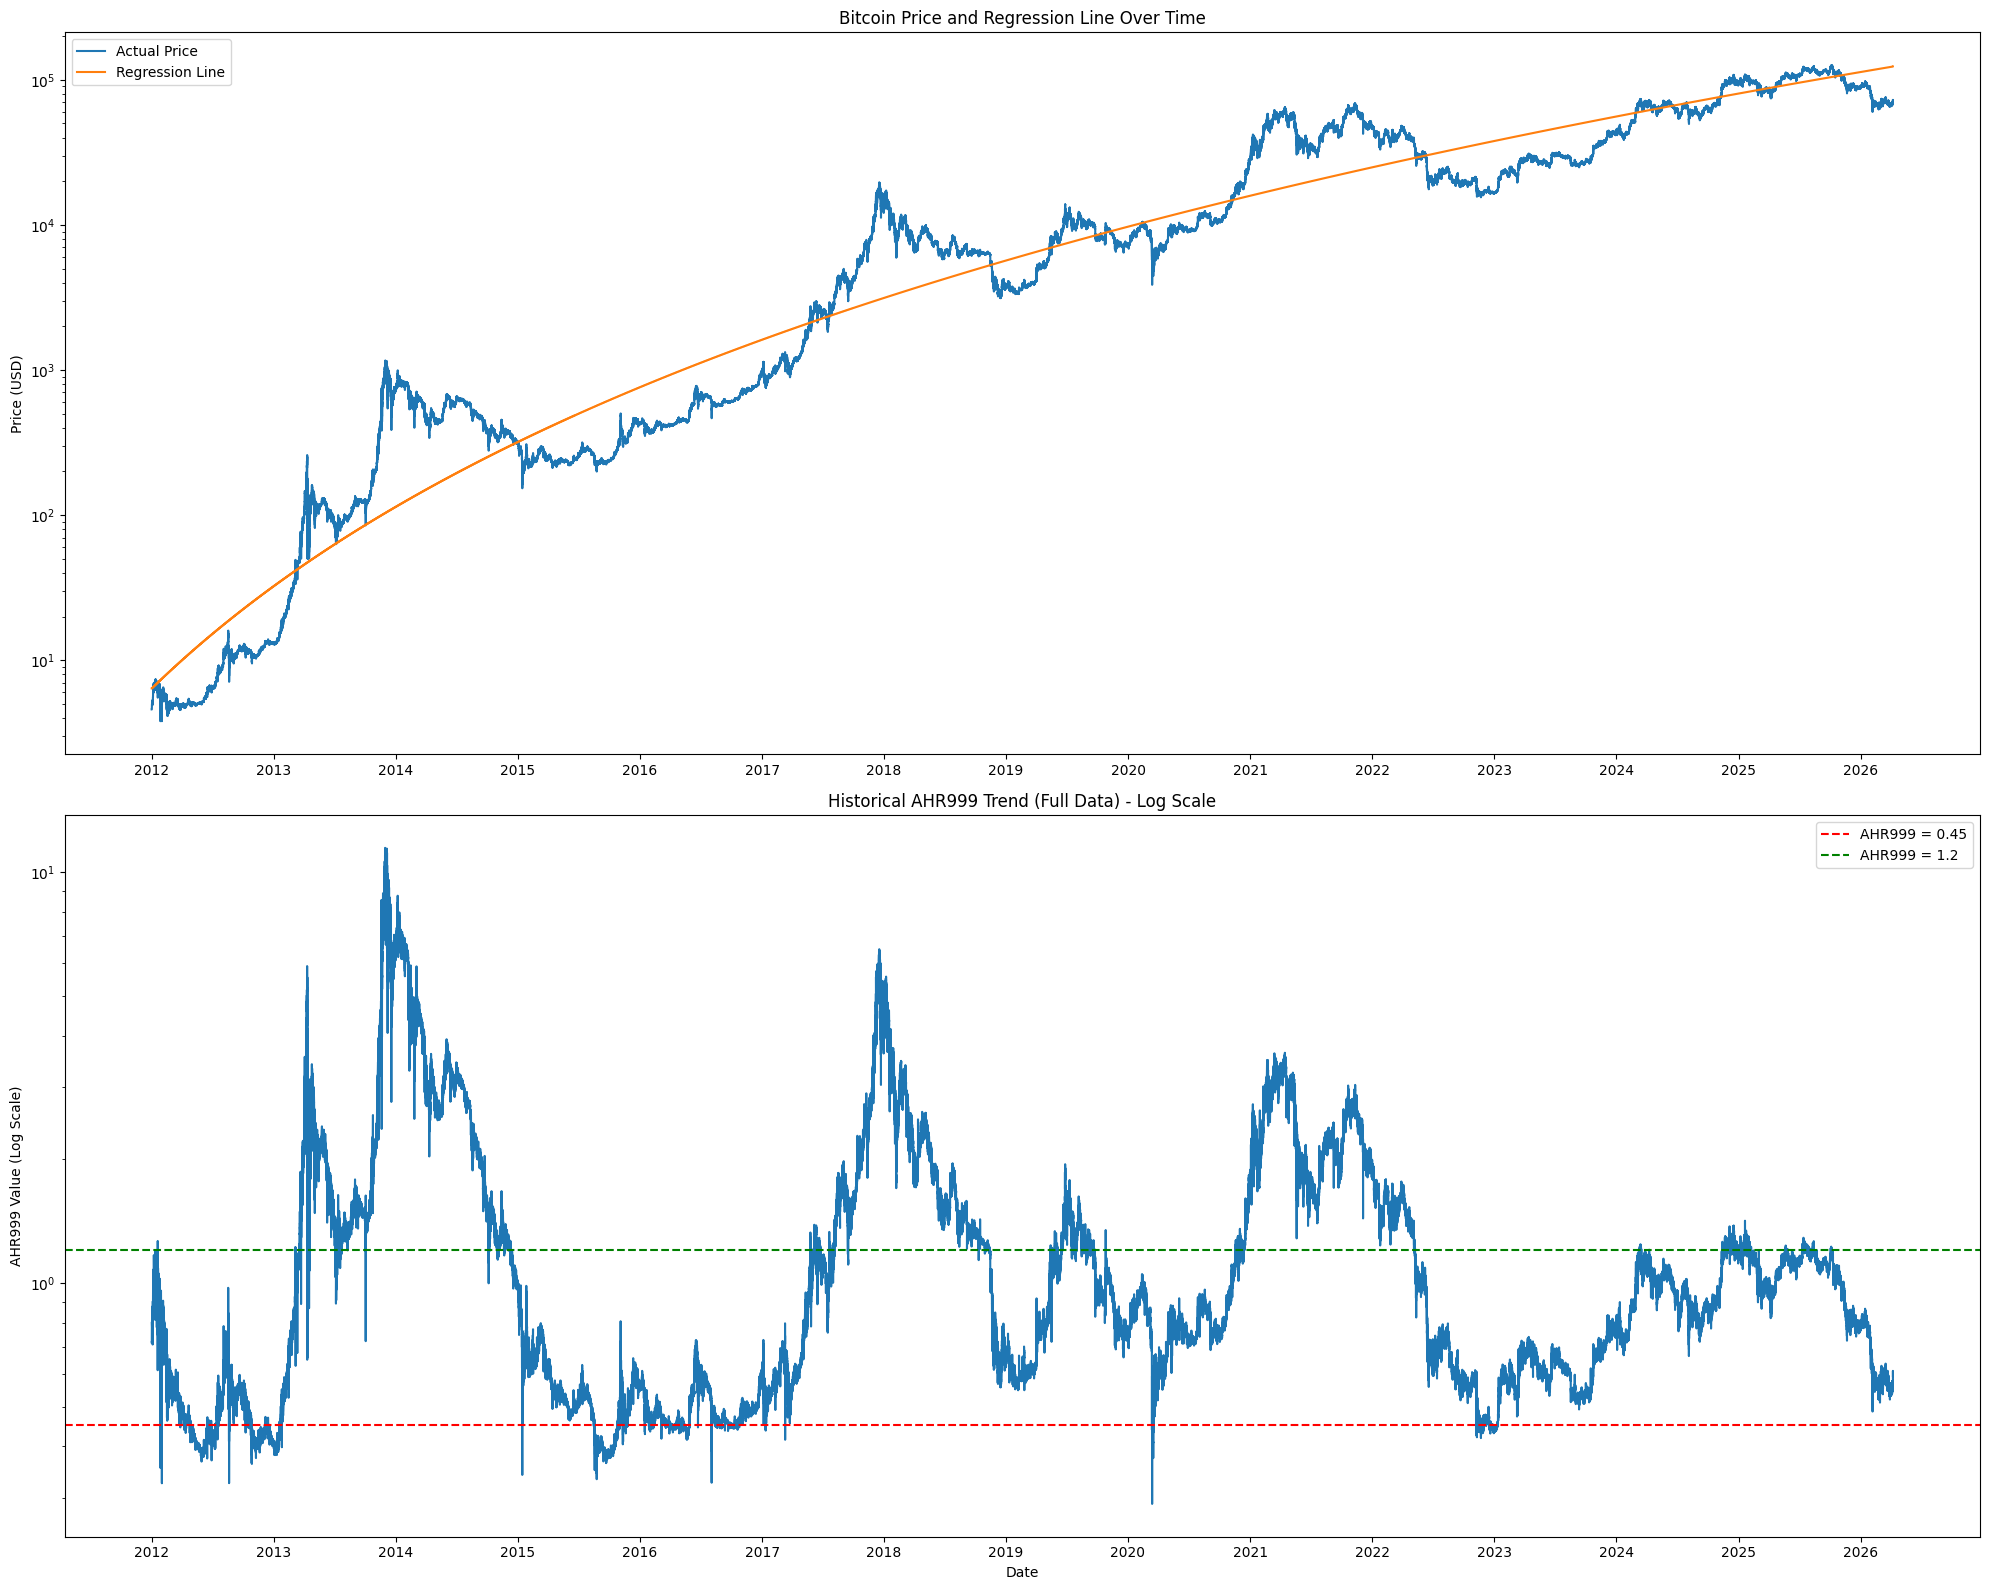

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# Create a figure with two subplots (2 rows, 1 column)
fig, axes = plt.subplots(2, 1, figsize=(20, 16))

# Plot price data and regression line in the first subplot
# Use the stored instance variables from the btc999 object
if btc999.dates is not None and btc999.ydata is not None and btc999.predicted_ydata is not None:
    axes[0].plot(btc999.dates, 10 ** btc999.ydata, label='Actual Price')
    axes[0].plot(btc999.dates, 10 ** btc999.predicted_ydata, label='Regression Line')
    if btc999.vs_currency == 'usd':
        axes[0].set_yscale("log")
    axes[0].set_ylabel("Price (USD)")
    axes[0].set_title("Bitcoin Price and Regression Line Over Time")
    axes[0].legend()
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[0].xaxis.set_major_locator(mdates.YearLocator())
else:
    axes[0].set_title("Regression data not available")
    print("Regression data not available. Please ensure calculate_wb has been run.")


# Calculate historical AHR999 values if not already available
if 'historical_ahr999_df_full' not in locals() or historical_ahr999_df_full.empty:
     # Assuming df is available from a previous cell
     if 'df' in locals() and not df.empty:
         historical_ahr999_df_full = btc999.calculate_historical_ahr999(df)
     else:
         print("Raw data (df) not available to calculate historical AHR999.")
         historical_ahr999_df_full = pd.DataFrame(columns=['Date', 'AHR999']) # Create empty DataFrame


# Plot historical AHR999 trend in the second subplot
if not historical_ahr999_df_full.empty:
    axes[1].plot(pd.to_datetime(historical_ahr999_df_full['Date']), historical_ahr999_df_full['AHR999'])
    axes[1].axhline(y=0.45, color='r', linestyle='--', label='AHR999 = 0.45')
    axes[1].axhline(y=1.2, color='g', linestyle='--', label='AHR999 = 1.2')
    axes[1].set_yscale("log")
    axes[1].set_title("Historical AHR999 Trend (Full Data) - Log Scale")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("AHR999 Value (Log Scale)")
    axes[1].legend()
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[1].xaxis.set_major_locator(mdates.YearLocator())
else:
    axes[1].set_title("Historical AHR999 data not available for plotting")


plt.tight_layout()
plt.show()